RF Accuracy: 0.93
XGB Accuracy: 0.93


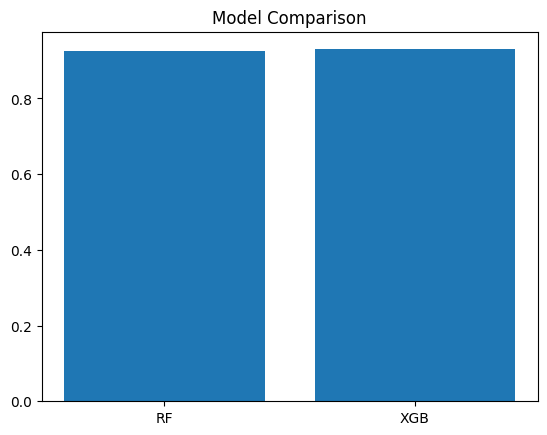

In [4]:
import joblib
import numpy as np
import polars as p1
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

X, y = make_classification(n_samples=1000, n_features=8, n_informative=4, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print(f"RF Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print(f"XGB Accuracy: {accuracy_score(y_test, xgb_pred):.2f}")

joblib.dump(rf, 'rf_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')

plt.bar(['RF', 'XGB'], [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)])
plt.title("Model Comparison")
plt.show()

In [3]:
import joblib
import polars as p1
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Dataset
X, y = make_classification(n_samples=1000, n_features=8, n_informative=4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Models
rf = RandomForestClassifier(random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# 3. Training
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

# 4. Predictions
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

# 5. Results
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.2f}")

# 6. Save (Deployment ke liye)
joblib.dump(rf, 'model_rf.pkl')
print("Model saved as model_rf.pkl")

Random Forest Accuracy: 0.93
Decision Tree Accuracy: 0.90
Model saved as model_rf.pkl
